---
title: "ggnomics: Reduced Dimension Plots"
format: html
execute:
  echo: true
  warning: false
---

In [8]:
os.chdir("..")

In [11]:
import importlib.util, os, sys
spec = importlib.util.spec_from_file_location("mock_data", os.path.join(os.getcwd(), "examples", "00_mock_data.py"))
mock_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mock_data)

from ggnomics import plot_reduced_dim

df    = mock_data.make_mock_df(n_cells=500)
adata = mock_data.make_mock_anndata(n_cells=500)
sce   = mock_data.make_mock_sce(n_cells=500)

## Overview

`plot_reduced_dim` visualises any 2-D cell embedding (UMAP, t-SNE, PCA, …)
stored in a DataFrame, AnnData, or SingleCellExperiment.  Point size adapts
automatically to the number of cells (Seurat-style: fewer cells → larger
points).

---

## 1 — DataFrame input

### Basic UMAP coloured by cluster

In [14]:
plot_reduced_dim

<function ggnomics.reduced_dim.plot_reduced_dim(data, dimred: 'str' = 'X_pca', components: 'Tuple[int, int]' = (1, 2), color: 'Optional[str]' = None, size: 'Optional[float]' = None, stroke: 'Optional[float]' = None, alpha: 'float' = 0.8, palette: 'Optional[Dict]' = None, title: 'Optional[str]' = None, legend_title: 'Optional[str]' = None, facet_by: 'Optional[str]' = None, order: 'Optional[List]' = None, layer: 'Optional[str]' = None, **kwargs) -> 'ggplot'>

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01a_umap_cluster.png


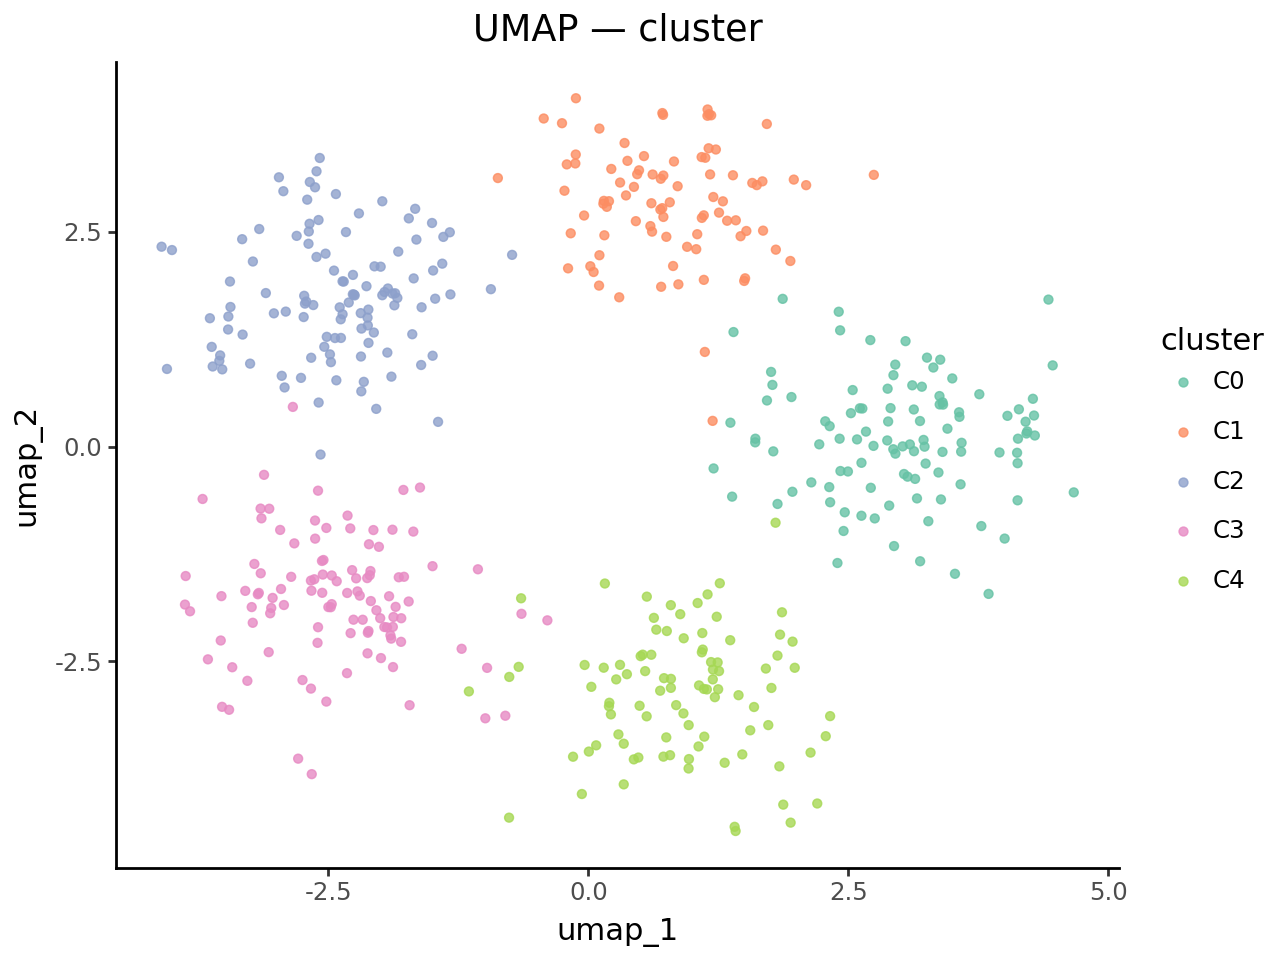

In [12]:
p = plot_reduced_dim(df, dimred="UMAP", color="cluster", title="UMAP — cluster")
p.save("examples/img/01a_umap_cluster.png", width=6, height=5, dpi=120)
p

### Colour by a continuous QC metric

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01b_umap_mito.png


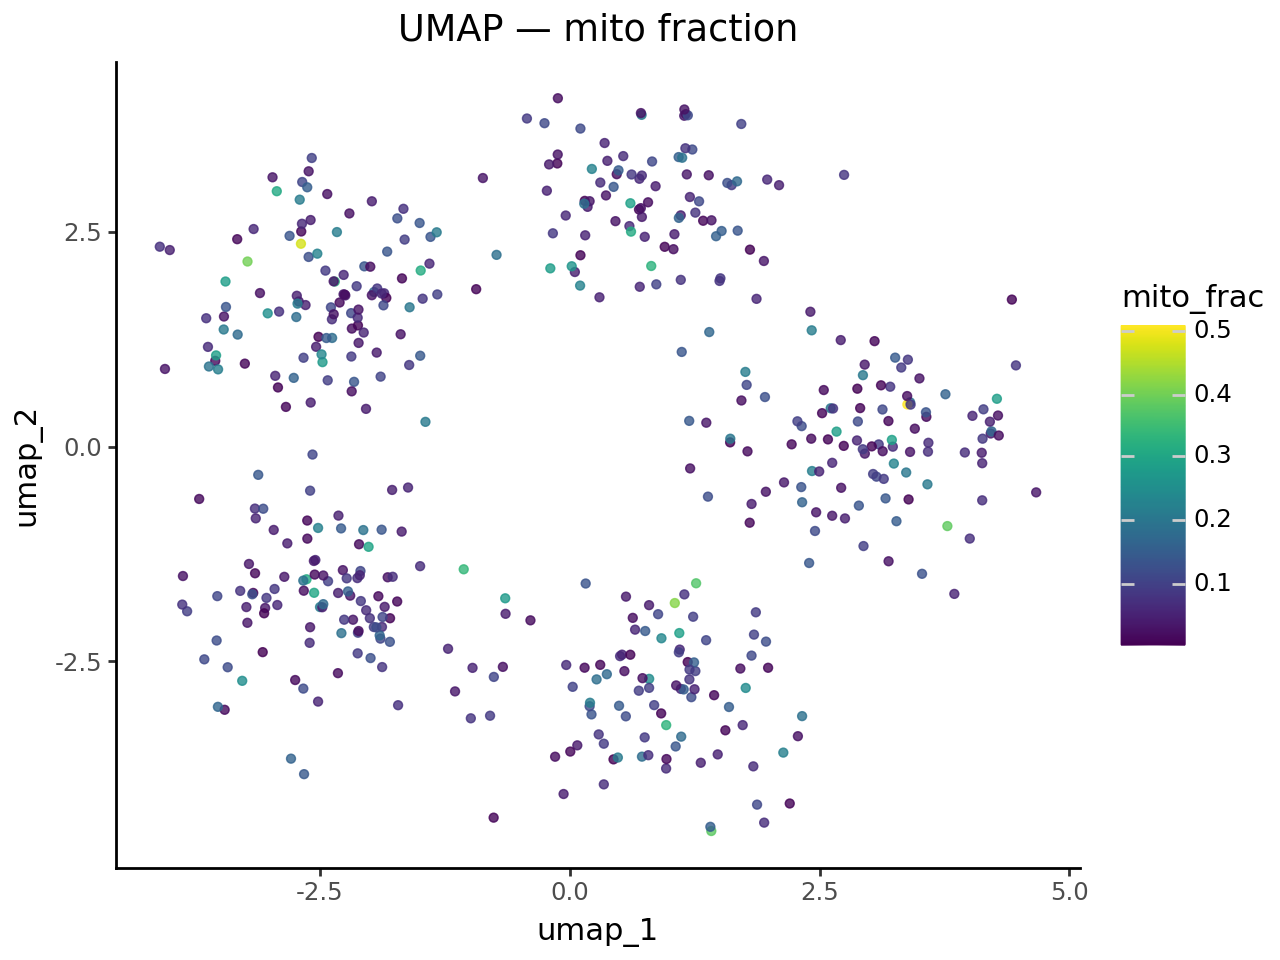

In [18]:
p = plot_reduced_dim(df, dimred="UMAP", color="mito_frac", title="UMAP — mito fraction", components=[1,2])
p.save("examples/img/01b_umap_mito.png", width=6, height=5, dpi=120, )
p

### PCA components 1 vs 2

In [ ]:
df

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01c_pca12.png


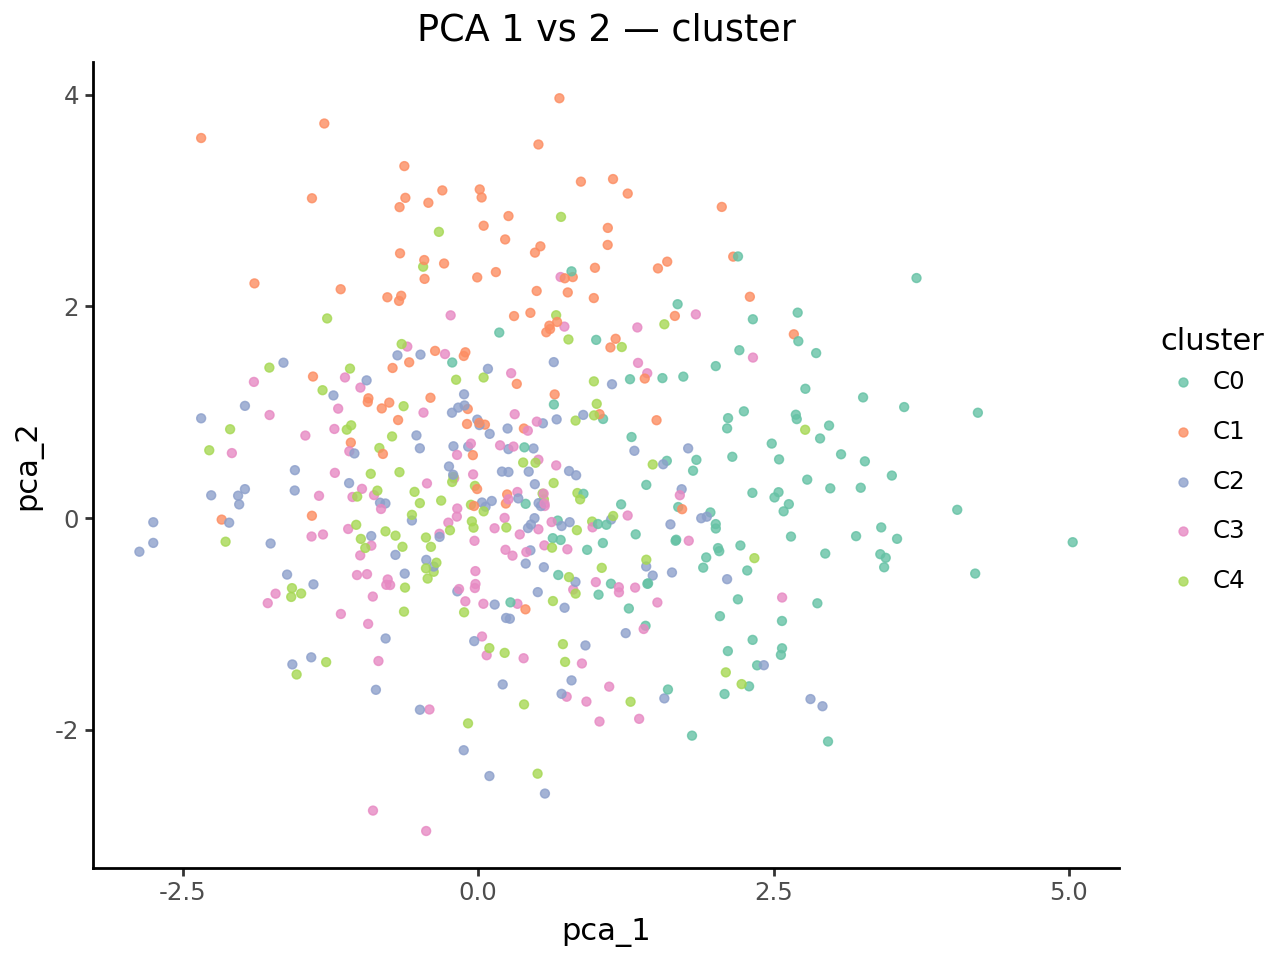

In [16]:
p = plot_reduced_dim(df, dimred="PCA", components=(1, 2), color="cluster",
                     title="PCA 1 vs 2 — cluster")
p.save("examples/img/01c_pca12.png", width=6, height=5, dpi=120)
p

### Facet by batch

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01d_umap_facet.png


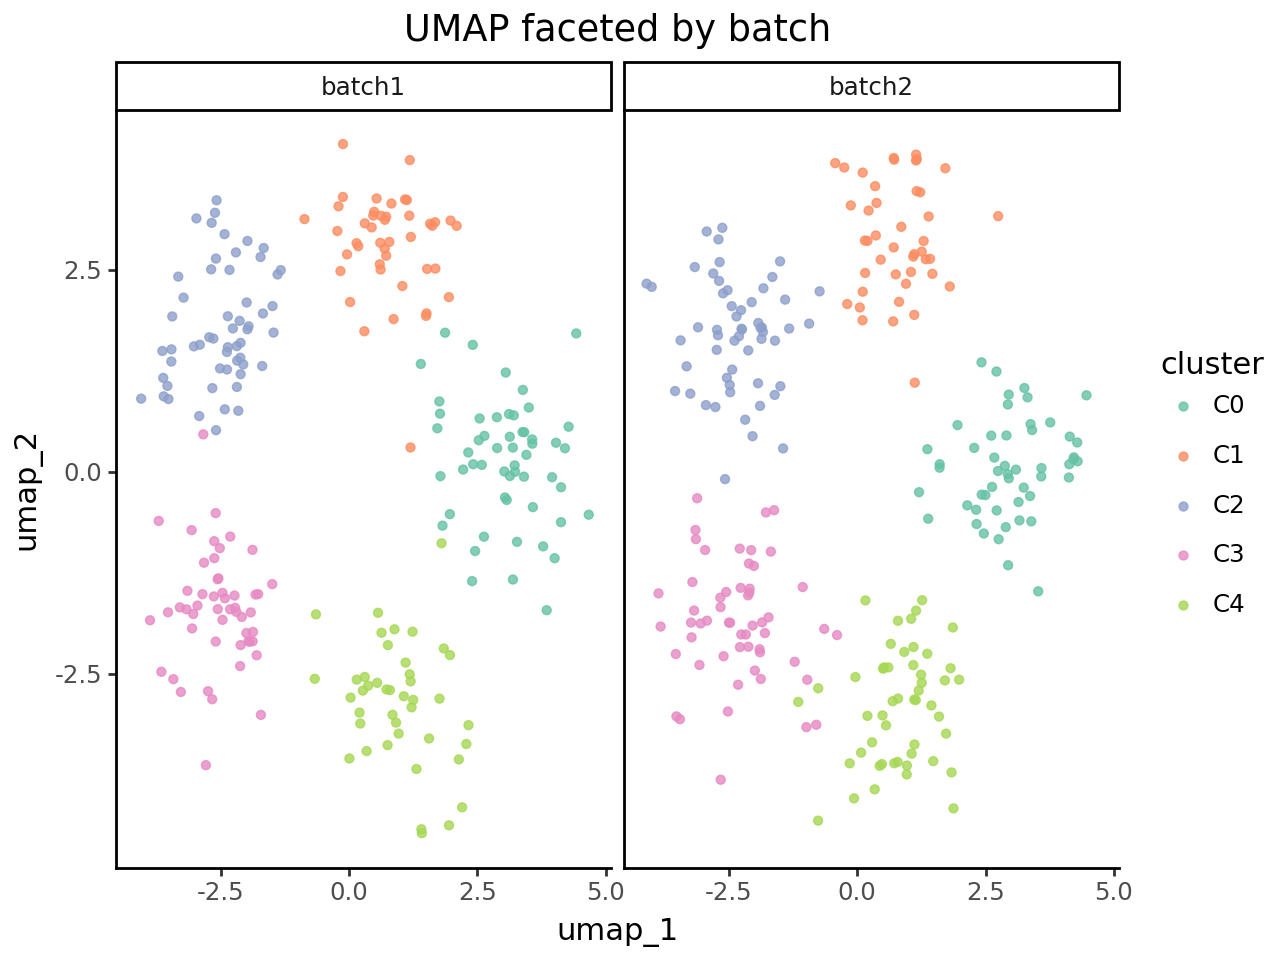

In [19]:
p = plot_reduced_dim(df, dimred="UMAP", color="cluster", facet_by="batch",
                     title="UMAP faceted by batch")
p.save("examples/img/01d_umap_facet.png", width=10, height=5, dpi=120)
p

### Order categories (draw last on top)

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01e_umap_order.png


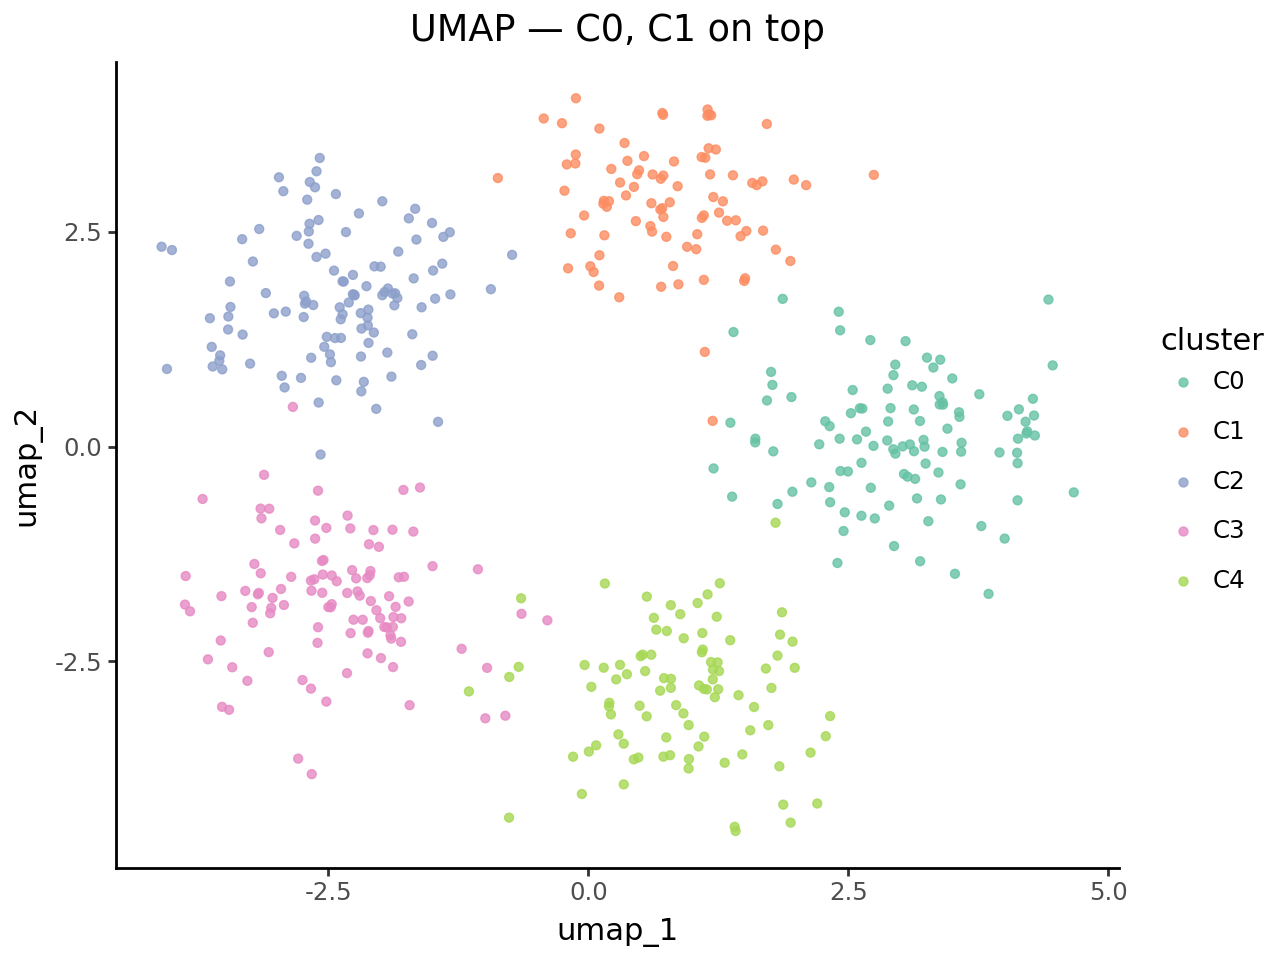

In [20]:
p = plot_reduced_dim(df, dimred="UMAP", color="cluster",
                     order=["C0", "C1"],  # C0 and C1 rendered on top
                     title="UMAP — C0, C1 on top")
p.save("examples/img/01e_umap_order.png", width=6, height=5, dpi=120)
p

### Gene expression as colour

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01f_umap_gene.png


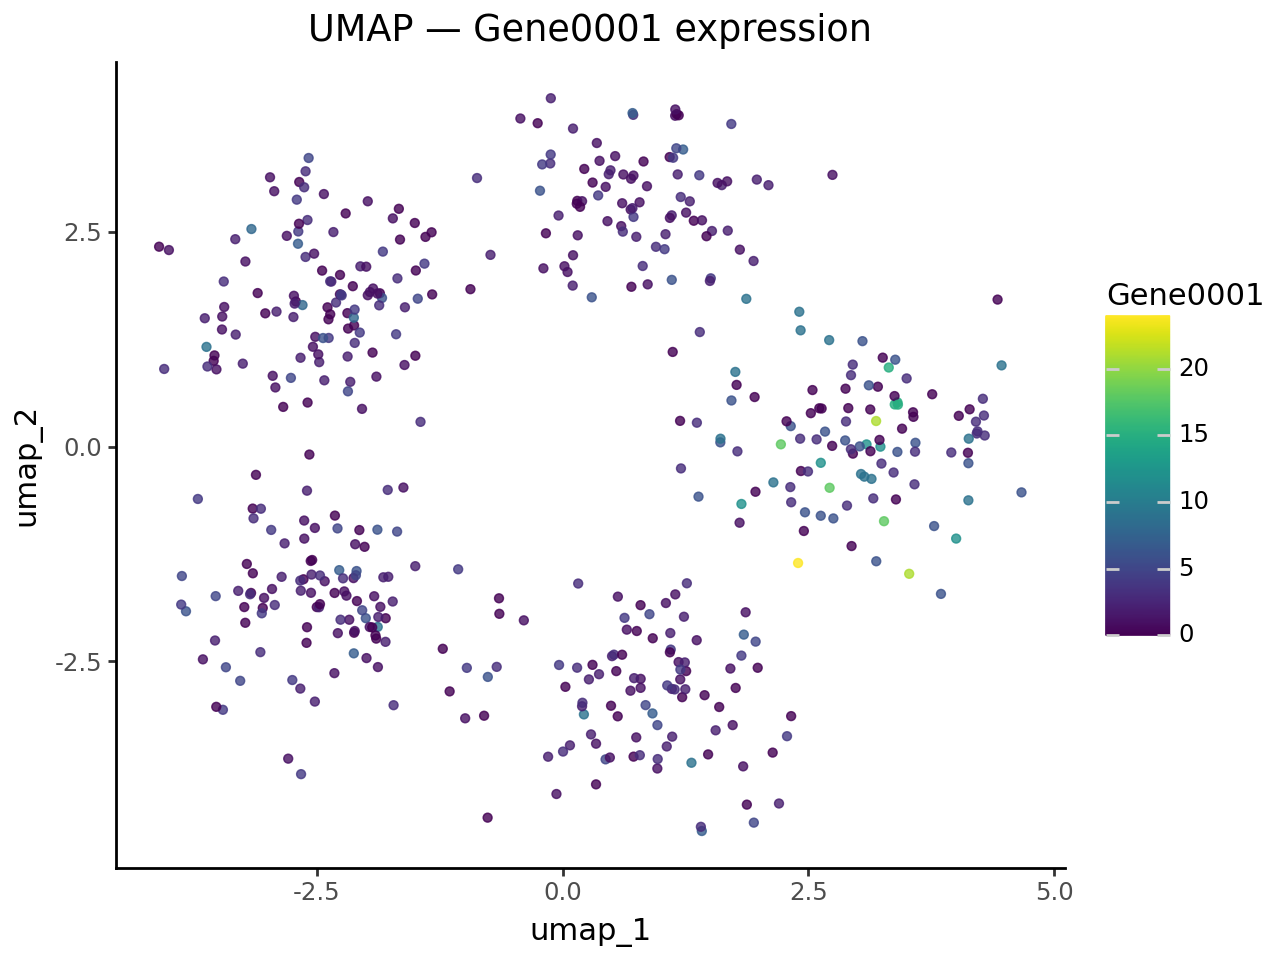

In [21]:
p = plot_reduced_dim(df, dimred="UMAP", color="Gene0001",
                     title="UMAP — Gene0001 expression")
p.save("examples/img/01f_umap_gene.png", width=6, height=5, dpi=120)
p

---

## 2 — AnnData input

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01g_adata_umap.png


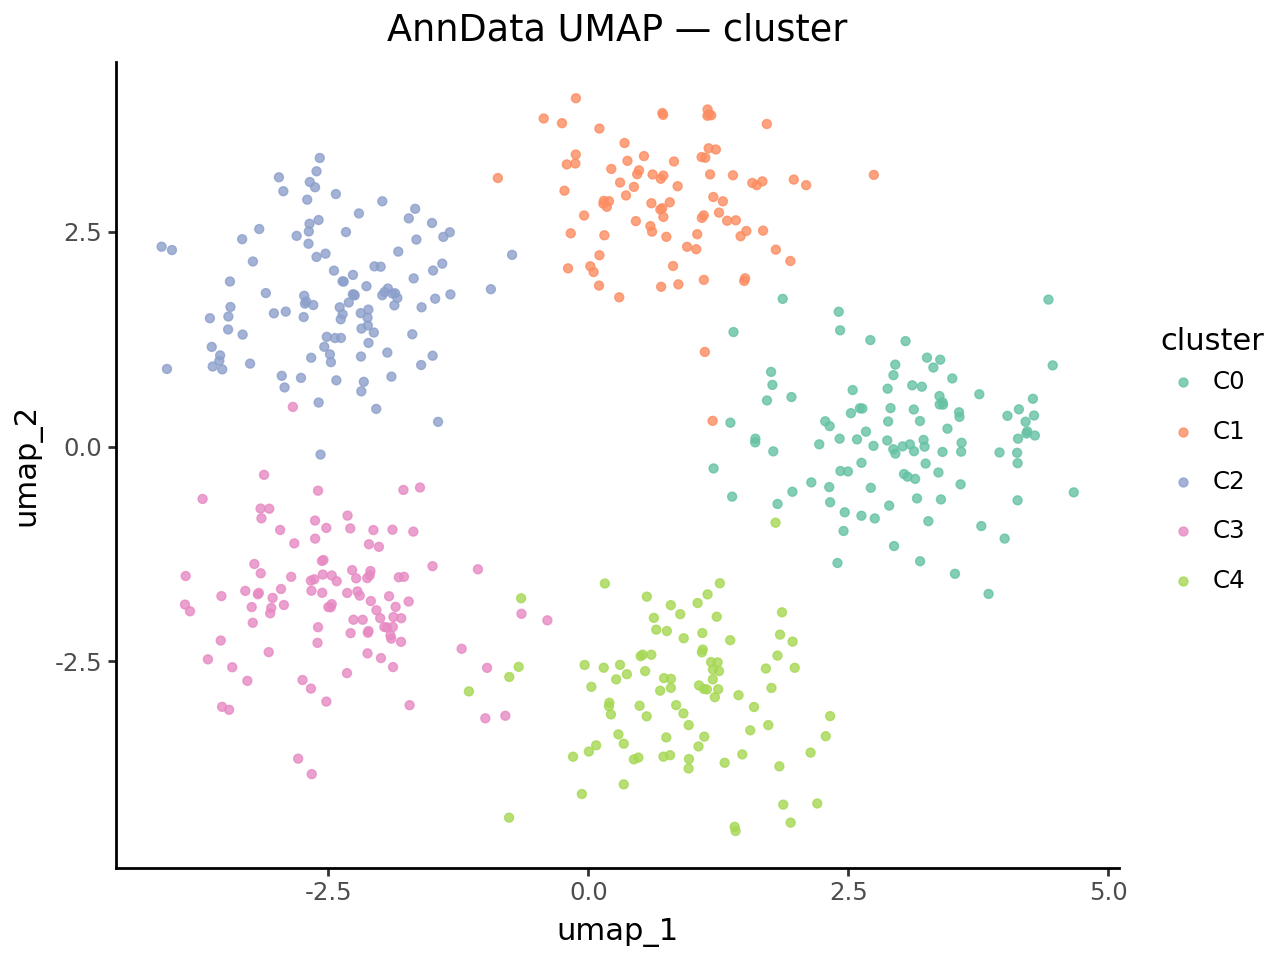

In [22]:
p = plot_reduced_dim(adata, dimred="X_umap", color="cluster",
                     title="AnnData UMAP — cluster")
p.save("examples/img/01g_adata_umap.png", width=6, height=5, dpi=120)
p

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01h_adata_gene.png


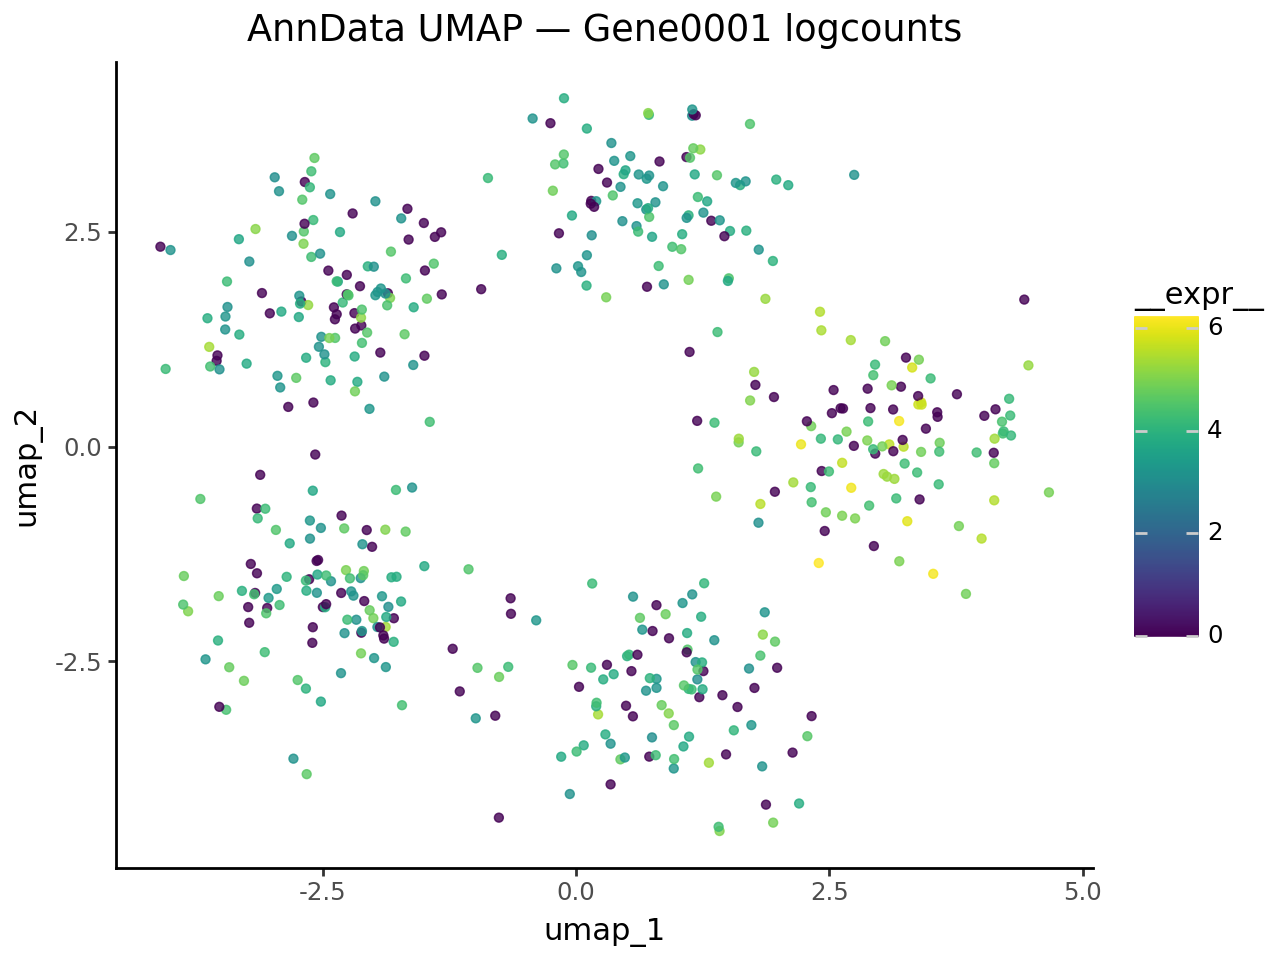

In [23]:
# Colour by gene expression from a specific layer
p = plot_reduced_dim(adata, dimred="X_umap", color="Gene0001",
                     layer="logcounts", title="AnnData UMAP — Gene0001 logcounts")
p.save("examples/img/01h_adata_gene.png", width=6, height=5, dpi=120)
p

---

## 3 — SingleCellExperiment input

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/01i_sce_umap.png


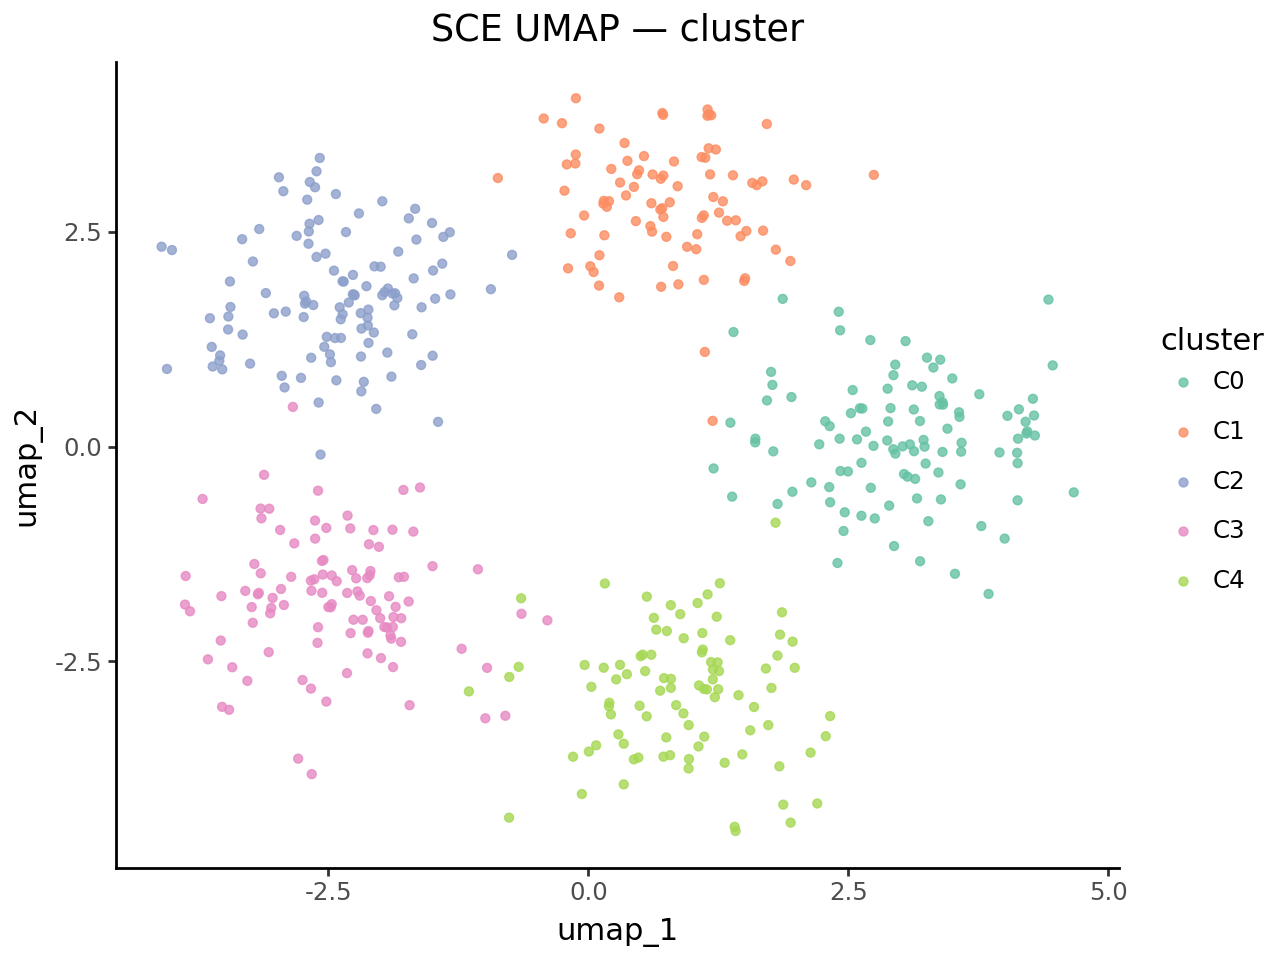

In [24]:
p = plot_reduced_dim(sce, dimred="UMAP", color="cluster",
                     title="SCE UMAP — cluster")
p.save("examples/img/01i_sce_umap.png", width=6, height=5, dpi=120)
p

---

## Key parameters

| Parameter | Description |
|-----------|-------------|
| `dimred` | Embedding key (e.g. `"X_umap"`, `"pca"`, `"UMAP"`) |
| `components` | 1-indexed tuple of which axes to plot (default `(1, 2)`) |
| `color` | Obs column **or** gene name |
| `size` / `stroke` | Point aesthetics; `None` → adaptive |
| `alpha` | Transparency 0–1 |
| `palette` | `{category: "#hex"}` dict for categorical colors |
| `facet_by` | Obs column for faceting |
| `order` | Draw listed categories last (on top) |
| `layer` | AnnData layer / SCE assay for gene expression |